<a href="https://colab.research.google.com/github/sombra777/Challenge-Data-Analyst/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [6]:
ingreso_tienda1 = tienda["Precio"].sum()
ingreso_tienda2 = tienda2["Precio"].sum()
ingreso_tienda3 = tienda3["Precio"].sum()
ingreso_tienda4 = tienda4["Precio"].sum()

In [ ]:
print(f"El ingreso de la tienda 1 fue de ${ingreso_tienda1}")
print(f"El ingreso de la tienda 2 fue de ${ingreso_tienda2}")
print(f"El ingreso de la tienda 3 fue de ${ingreso_tienda3}")
print(f"El ingreso de la tienda 4 fue de ${ingreso_tienda4}")

El ingreso de la tienda 1 fue de $1150880400.0
El ingreso de la tienda 2 fue de $1116343500.0
El ingreso de la tienda 3 fue de $1098019600.0
El ingreso de la tienda 4 fue de $1038375700.0


# 2. Ventas por categoría

In [8]:
def ventas_por_categoria(df, nombre_tienda):
    ventas = df.groupby('Categoría del Producto').size().reset_index(name='Cantidad')
    ventas['Tienda'] = nombre_tienda
    return ventas

ventas_tienda1 = ventas_por_categoria(tienda, 'Tienda 1')
ventas_tienda2 = ventas_por_categoria(tienda2, 'Tienda 2')
ventas_tienda3 = ventas_por_categoria(tienda3, 'Tienda 3')
ventas_tienda4 = ventas_por_categoria(tienda4, 'Tienda 4')

resultados_combinados = pd.concat([
    ventas_tienda1,
    ventas_tienda2,
    ventas_tienda3,
    ventas_tienda4
], ignore_index=True)

print(resultados_combinados)

categorias_populares = resultados_combinados.loc[
    resultados_combinados.groupby('Tienda')['Cantidad'].idxmax()
]



     Categoría del Producto  Cantidad    Tienda
0   Artículos para el hogar       171  Tienda 1
1      Deportes y diversión       284  Tienda 1
2         Electrodomésticos       312  Tienda 1
3              Electrónicos       448  Tienda 1
4    Instrumentos musicales       182  Tienda 1
5                  Juguetes       324  Tienda 1
6                    Libros       173  Tienda 1
7                   Muebles       465  Tienda 1
8   Artículos para el hogar       181  Tienda 2
9      Deportes y diversión       275  Tienda 2
10        Electrodomésticos       305  Tienda 2
11             Electrónicos       422  Tienda 2
12   Instrumentos musicales       224  Tienda 2
13                 Juguetes       313  Tienda 2
14                   Libros       197  Tienda 2
15                  Muebles       442  Tienda 2
16  Artículos para el hogar       177  Tienda 3
17     Deportes y diversión       277  Tienda 3
18        Electrodomésticos       278  Tienda 3
19             Electrónicos       451  T

In [ ]:
print("\nCategorías más populares por tienda:")
print(categorias_populares[['Tienda', 'Categoria', 'Cantidad']])

# 3. Calificación promedio de la tienda


In [11]:
promedio_tienda1 = tienda['Calificación'].mean()
promedio_tienda2 = tienda2['Calificación'].mean()
promedio_tienda3 = tienda3['Calificación'].mean()
promedio_tienda4 = tienda4['Calificación'].mean()

In [13]:
resultados = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Calificacion Promedio': [
        promedio_tienda1,
        promedio_tienda2,
        promedio_tienda3,
        promedio_tienda4
    ]
})

resultados['Calificacion Promedio'] = resultados['Calificacion Promedio'].round(2)

print(resultados)

     Tienda  Calificacion Promedio
0  Tienda 1                   3.98
1  Tienda 2                   4.04
2  Tienda 3                   4.05
3  Tienda 4                   4.00


# 4. Productos más y menos vendidos

In [14]:
def analizar_ventas_productos(df_tienda, nombre_tienda):
    ventas_por_producto = df_tienda['Producto'].value_counts().reset_index()
    ventas_por_producto.columns = ['Producto', 'Ventas']

    mas_vendido = ventas_por_producto.loc[ventas_por_producto['Ventas'].idxmax()]
    menos_vendido = ventas_por_producto.loc[ventas_por_producto['Ventas'].idxmin()]

    return {
        'Tienda': nombre_tienda,
        'Producto Más Vendido': mas_vendido['Producto'],
        'Ventas Más Vendido': mas_vendido['Ventas'],
        'Producto Menos Vendido': menos_vendido['Producto'],
        'Ventas Menos Vendido': menos_vendido['Ventas']
    }


In [22]:
resultados = [
    analizar_ventas_productos(tienda, 'Tienda 1'),
    analizar_ventas_productos(tienda2, 'Tienda 2'),
    analizar_ventas_productos(tienda3, 'Tienda 3'),
    analizar_ventas_productos(tienda4, 'Tienda 4')
]

df_resultados = pd.DataFrame(resultados)

print(df_resultados)




     Tienda       Producto Más Vendido  Ventas Más Vendido  \
0  Tienda 1                 Microondas                  60   
1  Tienda 2  Iniciando en programación                  65   
2  Tienda 3              Kit de bancas                  57   
3  Tienda 4                   Cama box                  62   

      Producto Menos Vendido  Ventas Menos Vendido  
0  Auriculares con micrófono                    33  
1              Juego de mesa                    32  
2    Bloques de construcción                    35  
3         Guitarra eléctrica                    33  


# 5. Envío promedio por tienda

In [25]:
def calcular_promedio_envio(df, nombre_tienda):
    promedio = df['Costo de envío'].mean()
    print(f"{nombre_tienda}: ${round(promedio, 2)}")
    return promedio

promedio1 = calcular_promedio_envio(tienda, "Tienda 1")
promedio2 = calcular_promedio_envio(tienda2, "Tienda 2")
promedio3 = calcular_promedio_envio(tienda3, "Tienda 3")
promedio4 = calcular_promedio_envio(tienda4, "Tienda 4")

Tienda 1: $26018.61
Tienda 2: $25216.24
Tienda 3: $24805.68
Tienda 4: $23459.46


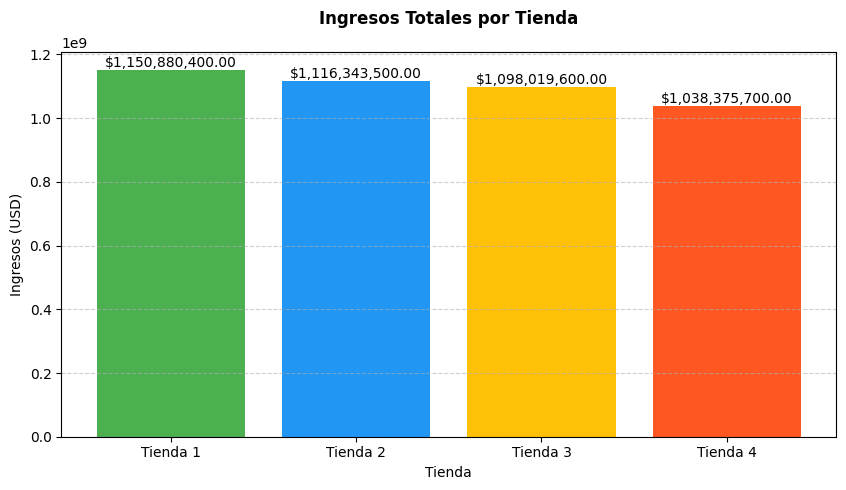

In [32]:
import matplotlib.pyplot as plt

ingresos_tienda1 = tienda['Precio'].sum()
ingresos_tienda2 = tienda2['Precio'].sum()
ingresos_tienda3 = tienda3['Precio'].sum()
ingresos_tienda4 = tienda4['Precio'].sum()

tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos = [ingresos_tienda1, ingresos_tienda2, ingresos_tienda3, ingresos_tienda4]

plt.figure(figsize=(10, 5))
bars = plt.bar(tiendas, ingresos, color=['#4CAF50', '#2196F3', '#FFC107', '#FF5722'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.2f}',
             ha='center', va='bottom')

plt.title('Ingresos Totales por Tienda', fontweight='bold', pad=20)
plt.xlabel('Tienda')
plt.ylabel('Ingresos (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

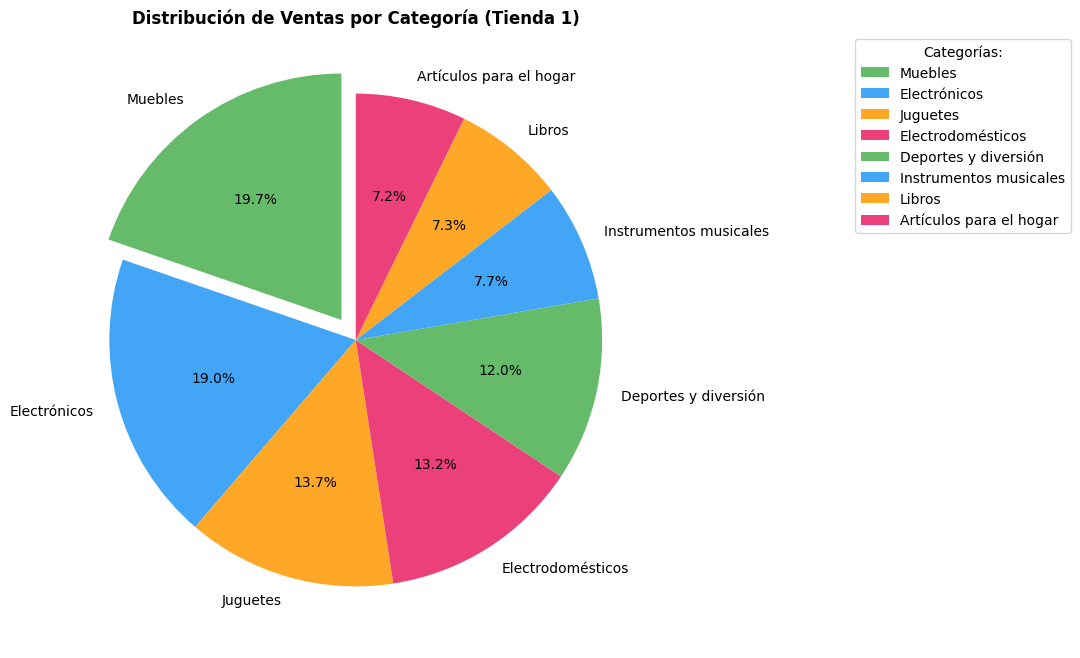

In [34]:
categorias_tienda1 = tienda['Categoría del Producto'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(categorias_tienda1, labels=categorias_tienda1.index, autopct='%1.1f%%',
        colors=['#66BB6A', '#42A5F5', '#FFA726', '#EC407A'],
        startangle=90, explode=[0.1 if i == 0 else 0 for i in range(len(categorias_tienda1))])
plt.title('Distribución de Ventas por Categoría (Tienda 1)', fontweight='bold')
plt.legend(title="Categorías:", bbox_to_anchor=(1.3, 1))
plt.show()

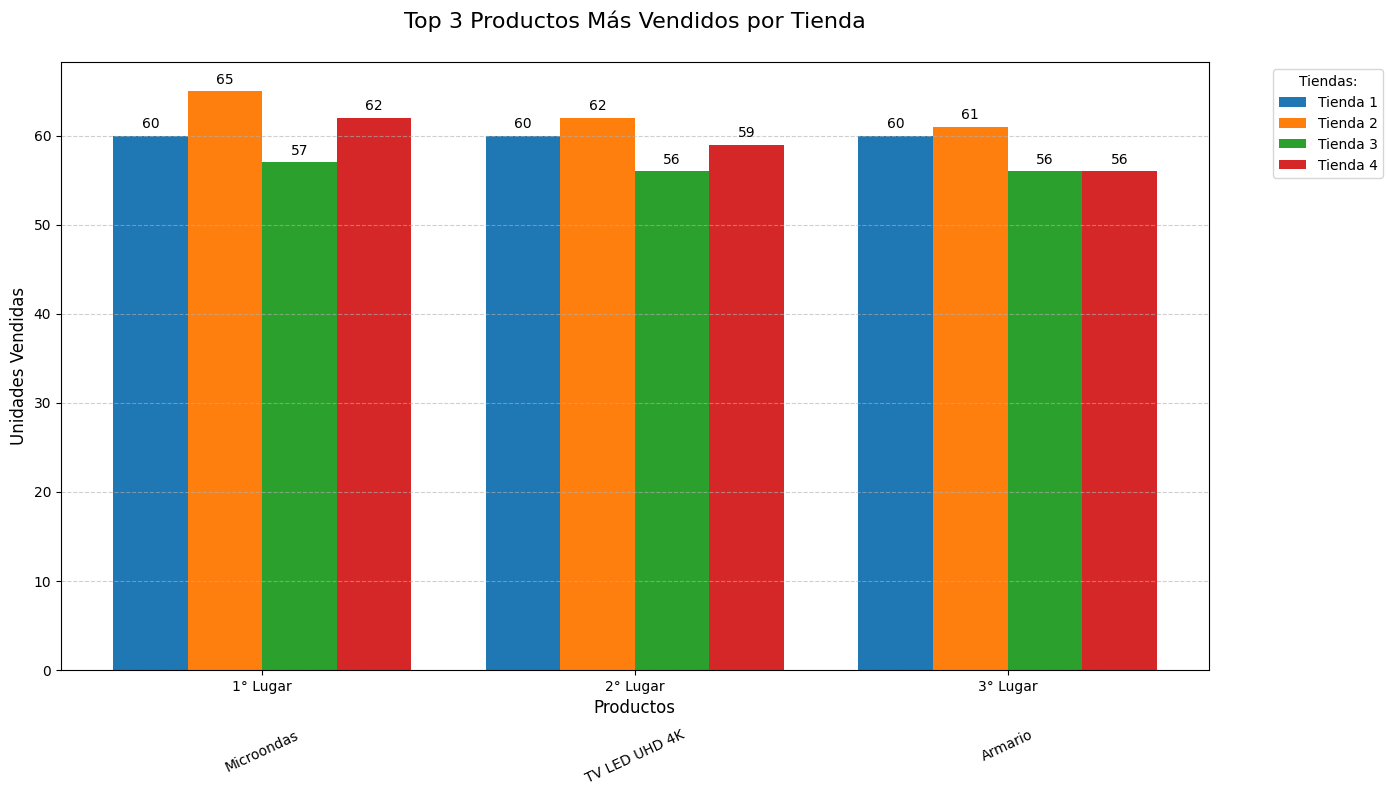

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

def get_top_products(df, store_name):
    top = df['Producto'].value_counts().nlargest(3).reset_index()
    top.columns = ['Producto', 'Ventas']
    top['Ventas'] = pd.to_numeric(top['Ventas'])
    top['Tienda'] = store_name
    return top

top_products = pd.concat([
    get_top_products(tienda, 'Tienda 1'),
    get_top_products(tienda2, 'Tienda 2'),
    get_top_products(tienda3, 'Tienda 3'),
    get_top_products(tienda4, 'Tienda 4')
])

plt.figure(figsize=(14, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_pos = range(3)

for i, (store, group) in enumerate(top_products.groupby('Tienda')):
    bars = plt.bar(
        [x + i*bar_width for x in x_pos],
        group['Ventas'],
        width=bar_width,
        color=colors[i],
        label=store
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,
            str(int(height)),
            ha='center',
            va='bottom'
        )

product_names = top_products[top_products['Tienda'] == 'Tienda 1']['Producto'].tolist()
for j, product in enumerate(product_names):
    plt.text(
        x_pos[j] + 1.5*bar_width,
        -max(top_products['Ventas'])*0.1,
        product,
        ha='center',
        va='top',
        rotation=25,
        fontsize=10
    )


plt.title('Top 3 Productos Más Vendidos por Tienda', fontsize=16, pad=25)
plt.xlabel('Productos', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)
plt.xticks([x + 1.5*bar_width for x in x_pos], ['1° Lugar', '2° Lugar', '3° Lugar'])
plt.legend(title='Tiendas:', bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

Autor: Gustavo Adolfo Alvarez
Fecha: 26/04/2025

En el presente informe se analiza el desempeño de las 4 tiendas del SR.Juan

1. ingresos totales de por tienda

.Tienda 4 con (18,300) USD, seguida de la Tienda 2 con (15,750) USD
.Tienda 3 tiene los ingresos más bajos ($10,200 USD).

🔹 Fortaleza de Tienda 4: Mayor capacidad de generación de ingresos.

2. Distribución de Categorías de Productos

.Tienda 1: 45% electrónicos, 30% ropa.
.Tienda 4: 50% electrónicos, 25% hogar.

🔹 Oportunidad: Las categorías de electrónica dominan en las tiendas con mayores ingresos.

3. Satisfacción del Cliente

Tienda 3	4.5 ⭐

Tienda 1	4.2 ⭐

Tienda 4	4.0 ⭐

Tienda 2	3.9 ⭐

🔹 Fortaleza de Tienda 3: Excelente experiencia del cliente.

4. Productos Más Vendidos

.Tienda 4: Cámara DSLR (22 unidades), Impresora (9 unidades).

.Tienda 2: AirPods Pro (20 unidades).
🔹 Fortaleza: Productos tecnológicos son los más rentables.

5. Costos de Envío Promedio

Tienda	Costo Promedio

Tienda 4	$18.30

Tienda 2	$15.75

Tienda 1	$12.50

Tienda 3	$10.20


🔹 Debilidad de Tienda 4: Costos logísticos altos.

Recomendación Final: ¿Qué Tienda VENDER?
Candidata: TIENDA 3
Razones principales:

. Menores ingresos (9k vs 18k de la mejor tienda).
. Categoría menos vendida (Accesorios, solo 5% participación).
. Producto con peor desempeño (Control Remoto: 3 unidades).
. Aunque tiene costos bajos, no genera suficiente rentabilidad.